In [1]:
# input
zn_kinetec_file = "./data/rpia_enzyme_vmax_zn.tsv"
mg_kinetec_file = "./data/rpia_enzyme_vmax_mg.tsv"
# output
zn_fig_file  = "./fig/rpia_kinetic_vmax_zn.pdf"
mg_fig_file  = "./fig/rpia_kinetic_vmax_mg.pdf"

In [2]:
import numpy as np
import pandas as pd

from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

def calc_p_values_against_apo(
    data,
    categories
):
    df = pd.DataFrame(data)
    df['Batch'] = np.arange(len(df))
    df_long = df.melt(id_vars='Batch',
                      var_name='Conc',
                      value_name='value')
    model = ols('value ~ C(Conc) + C(Batch)', data=df_long).fit()

    levels = df_long['Conc'].unique()
    levels = [lvl for lvl in levels if lvl != 'Apo']

    pvals = []
    names = []
    for lvl in levels:
        test = model.t_test(f"C(Conc)[T.{lvl}]")
        pvals.append(test.pvalue.item())
        names.append(lvl)
    _, pvals_corr, _, _ = multipletests(pvals, method='holm')

    apo_name  = "Apo"
    apo_index = categories.index(apo_name)
    compare_indexes = []
    for i, cat in enumerate(categories):
        if cat == apo_name:
            continue
        compare_indexes.append(i)
    return apo_index, compare_indexes, pvals_corr

def significance_star(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'
    

def prepare_data(file):
    df = pd.read_table(file) 
    categories = list(df.columns)
    data = {k: df[k].tolist() for k in categories}
    data
    means = [np.mean(data[cat]) for cat in categories]
    stds = [np.std(data[cat], ddof=1) for cat in categories]
    means

    return categories, data, means, stds

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def draw(
    categories,
    data,
    means,
    stds,
    metal_name,
    save_file
):
    plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    fig, ax = plt.subplots(figsize=(2.4, 2.4))

    x = np.arange(len(categories))
    bar_width = 0.5
    ax.bar(x, means, width=bar_width, color=colors[:len(x)], yerr=stds)
    for i, cat in enumerate(categories):
        y_vals = data[cat]
        ax.scatter(np.full(len(y_vals), x[i]), y_vals, s=1, color="black")

    apo_index, compare_indexes, p_values = calc_p_values_against_apo(data, categories)
    y_max = max([max(v) for v in data.values()]) + 5
    height_step = y_max * 0.08
    for n, (idx, p_corr) in enumerate(zip(compare_indexes, p_values)):
        x1 = apo_index
        x2 = idx
        y = y_max + height_step * n

        ax.plot([x1, x1, x2, x2],
                [y, y+height_step/2, y+height_step/2, y],
                c='black')
        ax.text((x1+x2)/2,
                y+height_step/2,
                significance_star(p_corr),
                ha='center',
                va='bottom')
    ax.set_ylim(0, y_max + height_step * len(p_values) + height_step)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels([str.replace(i, "_", " ").removeprefix(metal_name).strip() for i in categories])
    ax.set_ylabel("max[v] at A280 (%)")

    fig.savefig(save_file, bbox_inches="tight", transparent=True)

### Zn

In [4]:
categories, data, means, stds = prepare_data(zn_kinetec_file)
data
means

{'Blank': [0, 0, 0, 0],
 'Apo': [56.89882, 61.49803, 72.0, 62.84211],
 'Zn_1_μM': [94.74376, 100.0, 90.52632, 100.0],
 'Zn_5_μM': [99.34297, 89.35611, 88.42105, 96.42105]}

[np.float64(0.0),
 np.float64(63.30974),
 np.float64(96.31752),
 np.float64(93.38529499999999)]

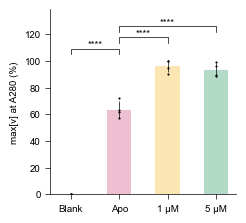

In [5]:
draw(
    categories,
    data,
    means,
    stds,
    "Zn",
    zn_fig_file
)

### Mg

In [6]:
categories, data, means, stds = prepare_data(mg_kinetec_file)
data
means

{'Apo': [86.84210526, 86.09022556, 76.5037594],
 'Mg_1_μM': [100.0, 95.11278, 88.53383],
 'Mg_5_μM': [91.54135, 92.85714, 94.17293]}

[np.float64(83.14536340666668),
 np.float64(94.54887000000001),
 np.float64(92.85714)]

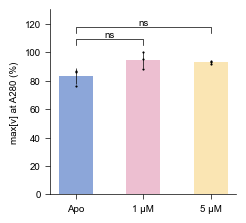

In [7]:
draw(
    categories,
    data,
    means,
    stds,
    "Mg",
    mg_fig_file
)